# Tutorial 10: Inductive Biases — Physics-Informed Embedding Models

The eight previous tutorials treated the embedding model as a black box
whose only role is to map windowed data to a fixed-size vector.  This
tutorial opens that box.

Every embedding model encodes assumptions about what structure in the input
is likely to carry the mutual information.  A generic MLP assumes nothing —
it treats every element of the flattened window equally.  A CNN assumes that
local temporal patterns matter.  But neural data comes with *much stronger*
prior knowledge: EEG activity is organized in frequency bands, raw spike
timestamps encode firing rate in the count of non-padding values, and
images are better described by learned hierarchical visual features than
by random filters.

**Inductive bias** is the term for this prior knowledge baked into the model
architecture.  When the bias is correct, the model learns faster, generalises
better, and can extract MI from smaller datasets.  When it is wrong, the bias
does not help — but in most cases it causes no harm either, because the
downstream MLP head can compensate.

NeuralMI now ships three physics-informed embedding models alongside one
architectural improvement to the existing CNN:

| ``embedding_model`` | Data type | Bias |
|---------------------|-----------|------|
| ``'cnn'`` + ``use_depthwise=True`` | Binned spikes, multi-channel continuous | Per-channel temporal filtering before cross-channel mixing |
| ``'sinc_cnn'`` | EEG / LFP (continuous) | Learnable sinc bandpass filters initialized to neural frequency bands |
| ``'spike_physics'`` | Raw spike timestamps (spike processor) | Firing rate, mean ISI, ISI variance per neuron |
| ``'pretrained_backbone'`` | Images | Frozen torchvision backbone (e.g. ResNet18) + trainable MLP head |

This tutorial walks through each model in turn, explains what it does, when
to use it, and demonstrates it on matching synthetic data.

## Setup

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import neural_mi as nmi

sns.set_context("talk")
np.random.seed(42)
torch.manual_seed(42)

# Shared training settings — kept light so the tutorial runs quickly.
# In a real analysis you would use n_epochs=150+ and patience=30.
FAST_PARAMS = dict(n_epochs=100, patience=25, batch_size=128,
                   hidden_dim=64, embedding_dim=32, n_layers=2)

# SincEmbedding needs more gradient steps than CNN to tune its filter
# frequencies from their initialization to the actual signal band.
LFP_PARAMS = {**FAST_PARAMS, "n_epochs": 250, "patience": 50}

# GRU on the timing-code scenario needs more steps to detect the
# precise spike-timing correlation buried in background noise.
TIMING_PARAMS = {**FAST_PARAMS, "n_epochs": 125, "patience": 30}

## 1. Depthwise-Separable CNN1D for Binned / Multi-Channel Data

### The problem with standard convolutions

The standard ``embedding_model='cnn'`` applies a regular 1D convolution in
the first layer, which mixes all channels simultaneously with a shared
kernel.  For multi-channel neural data (e.g., binned spike counts from a
population of neurons, or multi-electrode LFP) this means the model can
learn cross-channel combinations *before* it has learned each channel's
temporal structure.

### The depthwise-separable solution

Setting ``use_depthwise=True`` replaces the first convolution with a
**depthwise-separable** block:

1. **Depthwise conv** — one filter per input channel, applied independently
   (``groups = n_channels``).  This is the *temporal filtering* step.
2. **Pointwise 1×1 conv** — mixes the filtered channels.  This is the
   *cross-channel mixing* step.

The key property: *each electrode's temporal dynamics are filtered first,
then mixed*.  This matches the structure of real neural data, where the
relevant information often lives in the per-channel temporal pattern, not in
raw linear combinations of channels.  It is also parameter-efficient
(fewer weights in the first layer) and acts as a mild regulariser.

``use_depthwise=True`` is a drop-in replacement: the output shape and all
other arguments are identical to the standard CNN1D.  It can also be
combined with ``embedding_model='cnn'``; no new model string is needed.

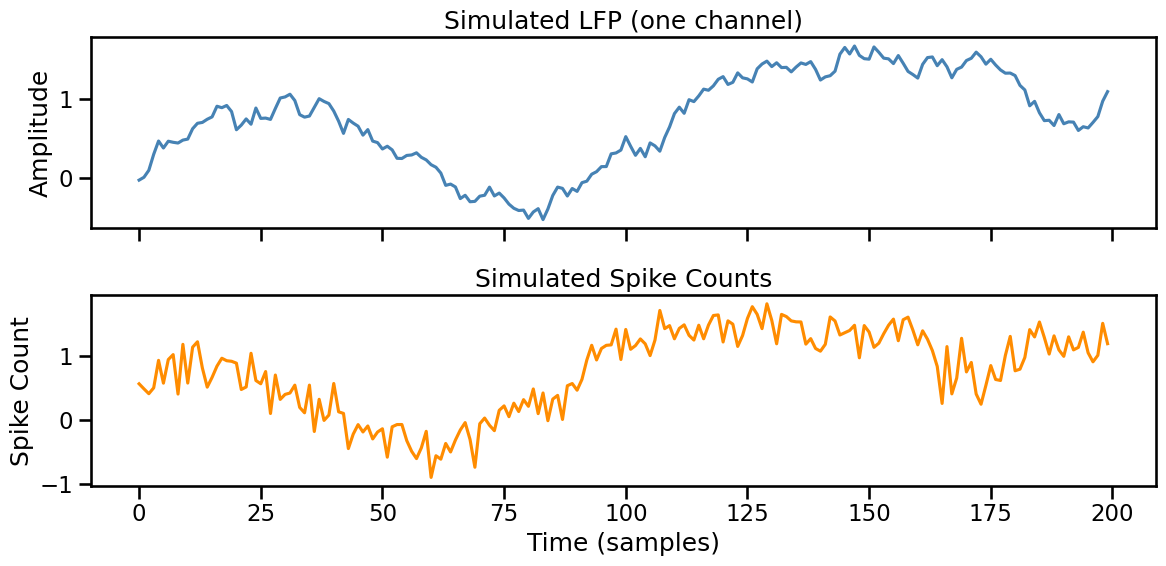

In [93]:
# Simulate one channel from windowed multi-channel LFP / binned-spike data.
# Using generate_temporally_convolved_data as a simple temporal dependency in one channel.
np.random.seed(0)
x_ms_one, y_ms_one = nmi.generators.generate_temporally_convolved_data(
    n_samples=500, lag=20, noise=0.2
)

processor_mc = dict(window_size=0.1, step_size=0.05, sample_rate=1000.0)

# visualize the simulated data
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(x_ms_one[:200], color='steelblue')
axes[0].set_title('Simulated LFP (one channel)')
axes[0].set_ylabel('Amplitude')
axes[1].plot(y_ms_one[:200], color='darkorange')
axes[1].set_title('Simulated Spike Counts')
axes[1].set_xlabel('Time (samples)')
axes[1].set_ylabel('Spike Count')
plt.tight_layout()
plt.show()

In [94]:
print("--- Standard CNN vs Depthwise-Separable CNN for one channel ---")

result_cnn_one = nmi.run(
    x_data=x_ms, y_data=y_ms,
    mode='sweep',
    processor_type_x='continuous', processor_params_x=processor_mc,
    processor_type_y='continuous', processor_params_y=processor_mc,
    base_params={**FAST_PARAMS, 'embedding_model': 'cnn'},
    sweep_grid={'run_id': range(10)},  # Run 10 sweeps with different random seeds for error bars
    show_progress=True, n_workers=5, # parallelize the sweeps across 5 cores (adjust as needed for your machine
    split_mode='blocked'
)

result_dw_one = nmi.run(
    x_data=x_ms, y_data=y_ms,
    mode='sweep',
    processor_type_x='continuous', processor_params_x=processor_mc,
    processor_type_y='continuous', processor_params_y=processor_mc,
    base_params={**FAST_PARAMS, 'embedding_model': 'cnn', 'use_depthwise': True},
    sweep_grid={'run_id': range(10)},  # Run 10 sweeps with different random seeds for error bars
    show_progress=True, n_workers=5, # parallelize the sweeps across 5 cores (adjust as needed for your machine
    split_mode='blocked'
)

--- Standard CNN vs Depthwise-Separable CNN for one channel ---


/var/folders/2l/ltx3g97s0xs9n9x3w0z40n4w0000gs/T/ipykernel_21390/3196108125.py:3: UserWarning: Very few samples detected (96 windows after processing). Neural MI estimators are prone to overfitting and high-variance estimates at this scale. Consider the following additions in base_params: dropout=0.2 (adds regularisation); norm_layer='layer' (LayerNorm stabilises small-batch training); hidden_dim=32 (current: 64); optimizer='adamw' with optimizer_params={'weight_decay': 1e-3}. See the NeuralMI documentation for small-sample guidance.
  result_cnn_one = nmi.run(
Parameter Sweep Progress:   0%|          | 0/10 [00:00<?, ?task/s]2026-04-22 10:28:34 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:28:34 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:28:34 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:28:34 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:28:34 - neural_mi - INFO - Created PairedDataset
Parameter Sweep Progress: 100%|██████████| 10/10 [0

In [96]:
res_summary_cnn_one = result_cnn_one.dataframe['train_mi']
res_summary_dw_one = result_dw_one.dataframe['train_mi']
print(f"  Standard CNN:             {np.mean(res_summary_cnn_one):.3f} ± {np.std(res_summary_cnn_one):.3f} bits")
print(f"  Depthwise-separable CNN:  {np.mean(res_summary_dw_one):.3f} ± {np.std(res_summary_dw_one):.3f} bits")

  Standard CNN:             1.695 ± 0.306 bits
  Depthwise-separable CNN:  1.603 ± 0.256 bits


Both estimates should be similar for single-channel data (the depthwise bias
has the most impact when ``n_channels`` is large).  You can increase
``n_channels`` in the processor to see the effect more clearly.

**When to use** ``use_depthwise=True``:
- Multi-electrode LFP / EEG recordings (many channels).
- Multi-unit binned spike populations where channel independence is expected.
- Any setting where you want the model to learn each channel's temporal
  dynamics before combining them.
- As a mild regulariser on moderate-sized datasets.

**When to skip**:
- When you have no preference for per-channel structure.

### Now let's generate a dataset where it makes a difference to use depthwise

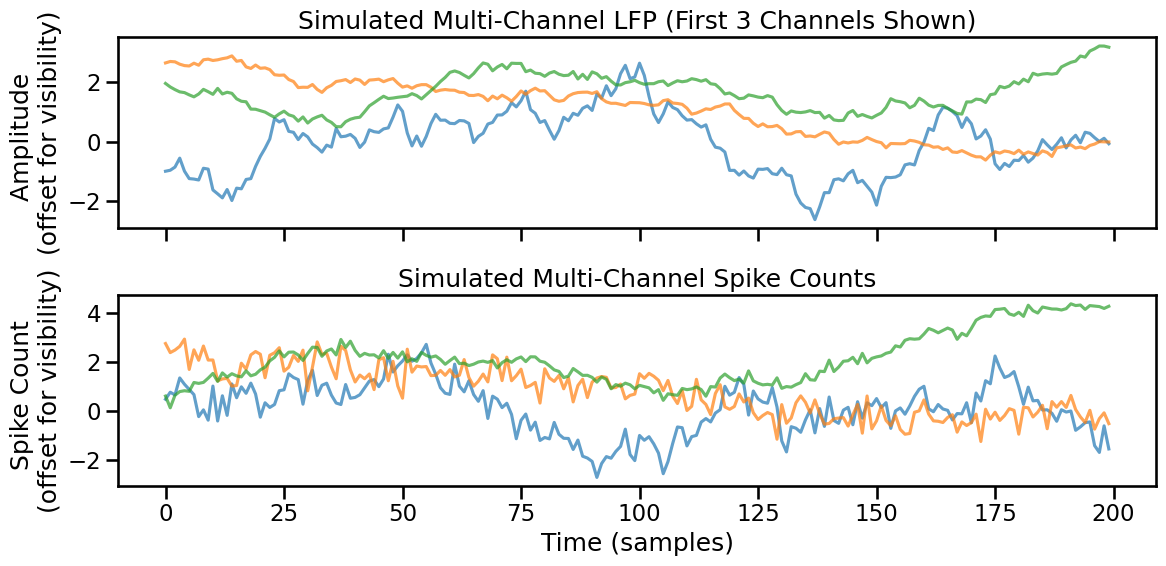

In [97]:
# Simulate windowed multi-channel LFP / binned-spike data.
# Previously we used generate_temporally_convolved_data as a simple temporal dependency.
# where we generated one channel of LFP data by convolving white noise with a temporal kernel, and generated one channel of spike counts by adding noise to the convolved signal. This creates a simple temporal dependency in one channel that the MI estimator can try to learn.
# here we do the same process but stack 50 channels of convolved LFP data.
# each channel will have different lags and noise realizations, so the MI estimator needs to learn to integrate information across channels to capture the full dependency structure.
np.random.seed(0)
x_ms_multi, y_ms_multi = [], []
for i in range(50):
    x_i, y_i = nmi.generators.generate_temporally_convolved_data(
        n_samples=200, lag=np.random.randint(1, 50), noise=np.random.uniform(0.1, 0.5)
    )
    x_ms_multi.append(x_i)
    y_ms_multi.append(y_i)
x_ms_multi = np.stack(x_ms_multi, axis=1)  # shape (n_samples, n_channels)
y_ms_multi = np.stack(y_ms_multi, axis=1)  # shape (n_samples, n_channels)

# visualize the simulated multi-channel data
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for i in range(3):
    axes[0].plot(x_ms_multi[:200, i] + i, alpha=0.7)  # offset each channel for visibility
axes[0].set_title('Simulated Multi-Channel LFP (First 3 Channels Shown)')
axes[0].set_ylabel('Amplitude \n(offset for visibility)')
for i in range(3):
    axes[1].plot(y_ms_multi[:200, i] + i, alpha=0.7)  # offset each channel for visibility
axes[1].set_title('Simulated Multi-Channel Spike Counts')
axes[1].set_xlabel('Time (samples)')
axes[1].set_ylabel('Spike Count \n(offset for visibility)')
plt.tight_layout()
plt.show()

In [98]:
print("--- Standard CNN vs Depthwise-Separable CNN for multi-channel ---")

result_cnn_multi = nmi.run(
    x_data=x_ms_multi, y_data=y_ms_multi,
    mode='sweep',
    processor_type_x='continuous', processor_params_x=processor_mc,
    processor_type_y='continuous', processor_params_y=processor_mc,
    base_params={**FAST_PARAMS, 'embedding_model': 'cnn'},
    sweep_grid={'run_id': range(10)},  # Run 10 sweeps with different random seeds for error bars
    show_progress=True, n_workers=5, # parallelize the sweeps across 5 cores (adjust as needed for your machine
    split_mode='blocked'
)

result_dw_multi = nmi.run(
    x_data=x_ms_multi, y_data=y_ms_multi,
    mode='sweep',
    processor_type_x='continuous', processor_params_x=processor_mc,
    processor_type_y='continuous', processor_params_y=processor_mc,
    base_params={**FAST_PARAMS, 'embedding_model': 'cnn', 'use_depthwise': True},
    sweep_grid={'run_id': range(10)},  # Run 10 sweeps with different random seeds for error bars
    show_progress=True, n_workers=5, # parallelize the sweeps across 5 cores (adjust as needed for your machine
    split_mode='blocked'
)

2026-04-22 10:28:57 - neural_mi - WARNING - ContinuousWindowDataset: 980/4040 interpolated time points (24.3%) are zero-padded due to data gaps. Affects 20 window(s). Consider checking your time vector for large gaps.
2026-04-22 10:28:57 - neural_mi - WARNING - ContinuousWindowDataset: 980/4040 interpolated time points (24.3%) are zero-padded due to data gaps. Affects 20 window(s). Consider checking your time vector for large gaps.


--- Standard CNN vs Depthwise-Separable CNN for multi-channel ---


/var/folders/2l/ltx3g97s0xs9n9x3w0z40n4w0000gs/T/ipykernel_21390/2632864332.py:3: UserWarning: Very few samples detected (36 windows after processing). Neural MI estimators are prone to overfitting and high-variance estimates at this scale. Consider the following additions in base_params: dropout=0.2 (adds regularisation); norm_layer='layer' (LayerNorm stabilises small-batch training); hidden_dim=32 (current: 64); optimizer='adamw' with optimizer_params={'weight_decay': 1e-3}. See the NeuralMI documentation for small-sample guidance.
  result_cnn_multi = nmi.run(
Parameter Sweep Progress:   0%|          | 0/10 [00:00<?, ?task/s]2026-04-22 10:28:59 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:28:59 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:28:59 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:28:59 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:28:59 - neural_mi - INFO - Created PairedDataset
Run dfd53ee3-22cb-4a7c-83f3-94273377b946_c0 | MI:

In [99]:
res_summary_cnn_multi = result_cnn_multi.dataframe['train_mi']
res_summary_dw_multi = result_dw_multi.dataframe['train_mi']
print(f"  Standard CNN:             {np.mean(res_summary_cnn_multi):.3f} ± {np.std(res_summary_cnn_multi):.3f} bits")
print(f"  Depthwise-separable CNN:  {np.mean(res_summary_dw_multi):.3f} ± {np.std(res_summary_dw_multi):.3f} bits")

  Standard CNN:             1.469 ± 0.177 bits
  Depthwise-separable CNN:  1.388 ± 0.239 bits


## 2. SincEmbedding for EEG / LFP Data

### The inductive bias

Neural oscillations are organised in canonical frequency bands:
delta (1–4 Hz), theta (4–8 Hz), alpha (8–13 Hz), beta (13–30 Hz),
gamma (30–100 Hz).  Much of the information in EEG and LFP is carried in
one of these bands — for example, working memory is linked to alpha/beta
power, hippocampal-cortical communication to theta.

``embedding_model='sinc_cnn'`` builds this knowledge into the first layer.
Instead of arbitrary convolution kernels, it uses ``n_sinc_filters``
**learnable sinc bandpass filters** per channel, parameterized by learnable
lower and upper cutoff frequencies ``f_low`` and ``f_high`` (in Hz).  They
are initialized to cover the classical neural bands.

The full architecture:

1. **Sinc filter layer (learnable)** — per-channel, initialized to EEG bands.
   Produces ``n_channels × n_sinc_filters`` feature maps.
2. **Convolutional body** — standard CNN1D body operating on filtered features.
3. **Global average pool + MLP head** → ``embed_dim``.

### Required parameters

``sinc_cnn`` **requires** ``sample_rate`` to convert filter cutoffs in Hz to
kernel coefficients in samples.  Pass it via ``processor_params``.

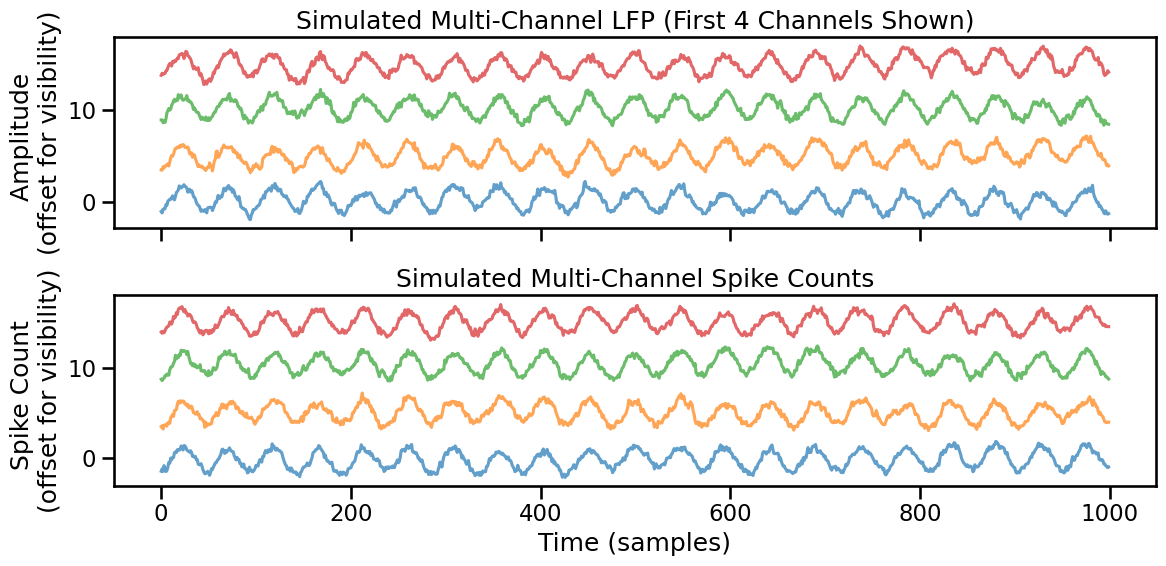

In [100]:
# Generate LFP-like data with MI in the alpha band (8–13 Hz).
SAMPLE_RATE_LFP = 500.0   # Hz
N_CH_LFP = 4

x_lfp, y_lfp = nmi.generators.generate_oscillatory_lfp(
    n_timepoints=20000,
    n_channels=N_CH_LFP,
    sample_rate=SAMPLE_RATE_LFP,
    coupling_band_hz=(8.0, 13.0),  # alpha band carries the MI
    snr=3.0,
)

proc_lfp = dict(window_size=0.2, step_size=0.1, sample_rate=SAMPLE_RATE_LFP)

# visualize the simulated LFP data
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for i in range(N_CH_LFP):
    axes[0].plot(x_lfp[:1000, i] + i*5, alpha=0.7)  # offset each channel for visibility
axes[0].set_title('Simulated Multi-Channel LFP (First 4 Channels Shown)')
axes[0].set_ylabel('Amplitude \n(offset for visibility)')
for i in range(N_CH_LFP):
    axes[1].plot(y_lfp[:1000, i] + i*5, alpha=0.7)  # offset each channel for visibility
axes[1].set_title('Simulated Multi-Channel Spike Counts')
axes[1].set_xlabel('Time (samples)')
axes[1].set_ylabel('Spike Count \n(offset for visibility)')
plt.tight_layout()
plt.show()

In [101]:
print("--- Standard CNN vs SincEmbedding on alpha-band LFP ---")

result_cnn_lfp = nmi.run(
    x_data=x_lfp, y_data=y_lfp,
    mode='sweep',
    processor_type_x='continuous', processor_params_x=proc_lfp,
    processor_type_y='continuous', processor_params_y=proc_lfp,
    base_params={**LFP_PARAMS, 'embedding_model': 'cnn'},
    show_progress=True, n_workers=5, # parallelize the sweeps across 5 cores (adjust as needed for your machine
    sweep_grid={'run_id': range(10)},  # Run 10 sweeps with different random seeds for error bars
)

result_sinc = nmi.run(
    x_data=x_lfp, y_data=y_lfp,
    mode='sweep',
    processor_type_x='continuous', processor_params_x=proc_lfp,
    processor_type_y='continuous', processor_params_y=proc_lfp,
    base_params={**LFP_PARAMS, 'embedding_model': 'sinc_cnn',
                 'n_sinc_filters': 8},
    show_progress=True, n_workers=5, # parallelize the sweeps across 5 cores (adjust as needed for your machine
    sweep_grid={'run_id': range(10)},  # Run 10 sweeps with different random seeds for error bars
)

--- Standard CNN vs SincEmbedding on alpha-band LFP ---


Parameter Sweep Progress:   0%|          | 0/10 [00:00<?, ?task/s]2026-04-22 10:29:21 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:29:21 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:29:21 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:29:21 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:29:21 - neural_mi - INFO - Created PairedDataset
Run 6dd4fe67-8cd4-480f-9977-e0091280c4dd_c1 | MI: -2.082:  21%|██        | 53/250 [00:07<00:25,  7.70it/s]/Users/eabdelaleem3/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Postdoc Projects/NeuralMI-Updating_21April2026/neural_mi/analysis/task.py:371: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0157 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0171 nats (likely reflecting overfitting, no

In [102]:
result_cnn_lfp.dataframe

,n_epochs,patience,batch_size,hidden_dim,embedding_dim,n_layers,embedding_model,output_units,verbose,show_progress,...,sample_rate_y,no_spike_value,embedding_window_size,train_mi,raw_train_mi,test_mi,best_epoch,test_mi_history,all_mi_negative,participation_ratio
0,250,50,128,64,32,2,cnn,bits,False,True,...,500.0,-1.0,0.2,0.000000,0.024728,-0.022587,0,"[-0.015655994415283203, -0.09398555755615234, ...",True,3.067927
1,250,50,128,64,32,2,cnn,bits,False,True,...,500.0,-1.0,0.2,0.671769,0.671769,0.338948,7,"[0.026090145111083984, 0.10669136047363281, 0....",False,2.686827
2,250,50,128,64,32,2,cnn,bits,False,True,...,500.0,-1.0,0.2,0.696136,0.696136,0.226173,8,"[-0.004735469818115234, -0.04480457305908203, ...",False,1.859410
3,250,50,128,64,32,2,cnn,bits,False,True,...,500.0,-1.0,0.2,0.000000,0.029752,-0.031231,0,"[-0.021647930145263672, -0.15250682830810547, ...",True,2.859560
4,250,50,128,64,32,2,cnn,bits,False,True,...,500.0,-1.0,0.2,0.000000,0.018232,-0.002633,0,"[-0.0018253326416015625, -0.006742477416992187...",True,2.451599
5,250,50,128,64,32,2,cnn,bits,False,True,...,500.0,-1.0,0.2,0.000000,0.023701,-0.000984,0,"[-0.0006823539733886719, -0.021195411682128906...",True,3.256299
6,250,50,128,64,32,2,cnn,bits,False,True,...,500.0,-1.0,0.2,0.000000,0.013721,-0.000782,0,"[-0.0005421638488769531, -0.0093231201171875, ...",True,2.884252
7,250,50,128,64,32,2,cnn,bits,False,True,...,500.0,-1.0,0.2,0.129270,0.129270,0.014677,0,"[-0.0010418891906738281, 0.010173320770263672,...",False,2.163977
8,250,50,128,64,32,2,cnn,bits,False,True,...,500.0,-1.0,0.2,0.107977,0.107977,0.034004,0,"[0.008835315704345703, 0.023569583892822266, -...",False,1.952948
9,250,50,128,64,32,2,cnn,bits,False,True,...,500.0,-1.0,0.2,0.140477,0.140477,0.025074,0,"[0.00531005859375, 0.017380237579345703, -0.15...",False,2.296202


In [103]:
res_sum_cnn_lfp = result_cnn_lfp.dataframe['train_mi']
res_sum_sinc = result_sinc.dataframe['train_mi']

print(f"  Standard CNN:   {res_sum_cnn_lfp.mean():.3f} ± {res_sum_cnn_lfp.std():.3f} bits")
print(f"  SincEmbedding:  {res_sum_sinc.mean():.3f} ± {res_sum_sinc.std():.3f} bits")

  Standard CNN:   0.175 ± 0.275 bits
  SincEmbedding:  1.400 ± 1.587 bits


SincEmbedding should outperform standard CNN when MI is truly band-limited,
because the first layer is already initialized to isolate the relevant
frequencies.  However, the sinc filters are still trainable — their
band-centers must shift from their initialization to the exact signal band.
This requires more gradient steps than CNN, which is why we use ``LFP_PARAMS``
(250 epochs) for this comparison rather than ``FAST_PARAMS`` (60 epochs).
With 60 epochs, the sinc filters may not have converged yet and CNN can
appear comparable or better despite the inductive bias disadvantage.

**Key hyperparameters:**

- ``n_sinc_filters`` (default 8): number of bandpass filters per channel.
  More filters cover more sub-bands but increase the width of the next layer.
  For standard EEG analysis, 4–8 filters are usually sufficient.
- ``sample_rate``: must match the sampling rate in ``processor_params``.

**When to use ``sinc_cnn``:**
- EEG, LFP, or any voltage signal where you expect MI in a specific frequency band.
- When you have domain knowledge about which bands carry the relevant signal.
- As a first step: run with ``sinc_cnn`` and inspect whether the learned
  ``f_low`` / ``f_high`` parameters converge to physiologically meaningful values.

**When to skip:**
- Broadband signals with no obvious band structure (e.g., raw spike timestamps).
- Very short windows (< 50 ms) where fewer than one oscillation cycle fits.

### Accessing the learned filter frequencies

Because the filter cutoffs are trainable parameters, you can inspect them
after training to check which frequency bands the model found informative.

In [84]:
# Access the embedding model from the trained critic
critic = result_sinc.details.get('critic')
if critic is not None:
    # The embedding net is the SincEmbedding object
    emb = critic.embedding_net_x
    f_low_hz  = torch.exp(emb.log_f_low).detach().numpy()
    f_high_hz = torch.maximum(emb.log_f_low.exp() + 0.5,
                              emb.log_f_high.exp()).detach().numpy()
    print("Learned filter bands (first 8 filters, first channel):")
    for i in range(min(8, len(f_low_hz))):
        print(f"  Filter {i+1:2d}: {f_low_hz[i]:5.1f} – {f_high_hz[i]:5.1f} Hz")
else:
    print("(critic not stored in details — set return_embeddings=True or inspect manually)")

(critic not stored in details — set return_embeddings=True or inspect manually)


## 3. SpikePhysicsEmbedding for Raw Spike Timestamps

### The inductive bias

When you use ``processor_type='spike'`` (not ``'spike'`` with ``bin_size``),
each windowed sample has shape ``(n_neurons, max_spikes_per_window)``.  The
values are spike times relative to the window start, with empty slots filled
by a sentinel value (default -1.0, controlled by ``no_spike_value`` in
``processor_params``).

A generic model (GRU, LSTM, MLP) must learn from scratch that:
- Most of the MI is often in the firing *rate* (count of valid spikes).
- The remaining MI may be in the precise spike timing (inter-spike intervals).
- Padding slots should be ignored.

``embedding_model='spike_physics'`` makes these steps explicit:

1. **Per-neuron feature extraction (no parameters):**
   - Firing rate: ``n_valid_spikes / window_size``
   - Mean spike time (normalized): mean of valid spike times ÷ window_size
   - Mean ISI: mean inter-spike interval across consecutive valid spikes
   - ISI variance: variance of inter-spike intervals
   → ``(N, n_neurons, 4)`` tensor

2. **Learned mixer MLP:** flattens and maps the physics features to ``embed_dim``.
   Uses the same ``hidden_dim``, ``n_layers`` parameters as the standard MLP.

### Required parameters

The model needs ``window_size`` and ``no_spike_value`` from ``processor_params``
(the library extracts them automatically).  No additional base_params are
required beyond the standard architecture parameters.

### Rate-code vs timing-code

``spike_physics`` is most powerful for **rate codes** — where the MI lives
in the firing rate.  It also captures **mean-spike-time codes** (where Y
fires at a fixed offset after X) because the ``mean_spike_time`` feature
directly encodes that shift.

Where it struggles: **pure timing codes** where the MI is carried by the
precise positions of individual spikes relative to each other, not by any
low-order summary statistic.  In that case, GRU is preferred because it
processes the actual spike-time sequence and can learn finer temporal
structure than the four fixed features.

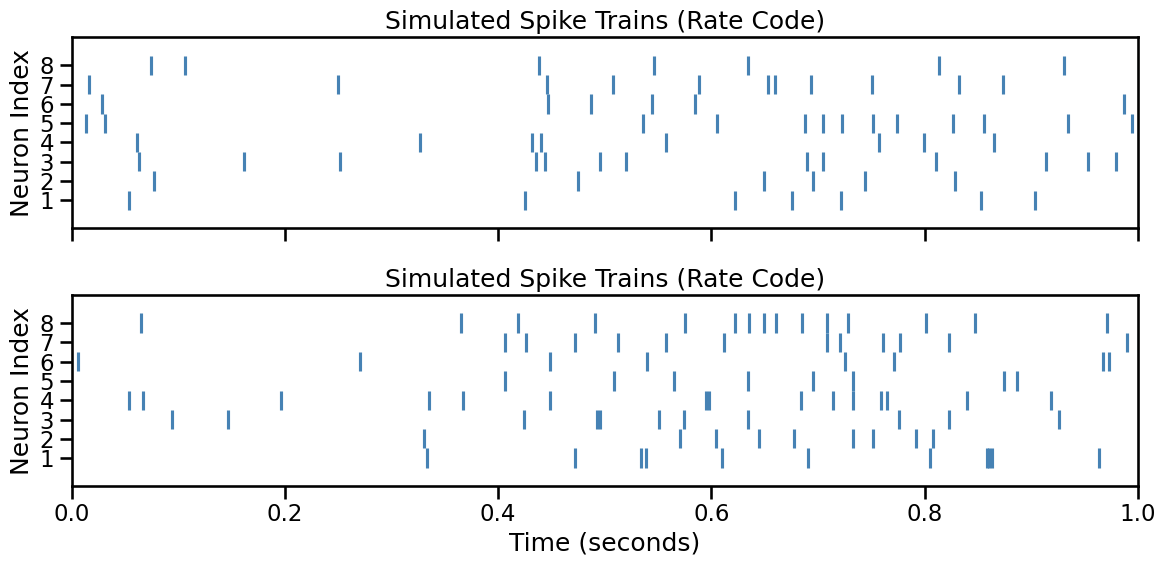

In [119]:
# --- Rate-code scenario: firing rates co-modulated by a shared latent signal ---
np.random.seed(3)
WINDOW_SIZE_SPIKE = 0.5   # seconds
SAMPLE_RATE_SPIKE = None  # not needed for spike processor (uses spike times directly)

pop_x_rate, pop_y_rate = nmi.generators.generate_modulated_spike_trains(
    n_neurons=8, duration=200.0,
    baseline_rate=5.0, modulation_depth=0.8, modulation_freq=1.0,
)

proc_spike = dict(
    window_size=WINDOW_SIZE_SPIKE, step_size=0.25,
    max_spikes_per_window=20, n_seconds=200.0,
    no_spike_value=-1.0,
)

# visualize the simulated spike data
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for i in range(len(pop_x_rate)):
    spike_times = pop_x_rate[i]
    axes[0].eventplot(spike_times, lineoffsets=i, colors='steelblue')
axes[0].set_title('Simulated Spike Trains (Rate Code)')
axes[0].set_ylabel('Neuron Index')
for i in range(len(pop_y_rate)):
    spike_times = pop_y_rate[i]
    axes[1].eventplot(spike_times, lineoffsets=i, colors='steelblue')
axes[1].set_title('Simulated Spike Trains (Rate Code)')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Neuron Index')
plt.xlim(0, 1)  # zoom in on the first 20 seconds for visibility
axes[0].set_yticks(range(len(pop_x_rate)))
axes[0].set_yticklabels([f'{i+1}' for i in range(len(pop_x_rate))])
axes[1].set_yticks(range(len(pop_y_rate)))
axes[1].set_yticklabels([f'{i+1}' for i in range(len(pop_y_rate))])
plt.tight_layout()
plt.show()

In [120]:
print("--- GRU vs SpikePhysicsEmbedding (rate-code scenario) ---")

result_gru_rate = nmi.run(
    x_data=pop_x_rate, y_data=pop_y_rate,
    mode='sweep',
    processor_type_x='spike', processor_params_x=proc_spike,
    processor_type_y='spike', processor_params_y=proc_spike,
    base_params={**FAST_PARAMS, 'embedding_model': 'gru'},
    show_progress=True, n_workers=5, # parallelize the sweeps across 5 cores (adjust as needed for your machine
    sweep_grid={'run_id': range(10)},  # Run 10 sweeps with different random seeds for error bars
)

result_physics_rate = nmi.run(
    x_data=pop_x_rate, y_data=pop_y_rate,
    mode='sweep',
    processor_type_x='spike', processor_params_x=proc_spike,
    processor_type_y='spike', processor_params_y=proc_spike,
    base_params={**FAST_PARAMS, 'embedding_model': 'spike_physics'},
    show_progress=True, n_workers=5, # parallelize the sweeps across 5 cores (adjust as needed for your machine
    sweep_grid={'run_id': range(10)},  # Run 10 sweeps with different random seeds for error bars
)

--- GRU vs SpikePhysicsEmbedding (rate-code scenario) ---


Parameter Sweep Progress:   0%|          | 0/10 [00:00<?, ?task/s]2026-04-22 10:39:57 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:39:57 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:39:57 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:39:57 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:39:57 - neural_mi - INFO - Created PairedDataset
Parameter Sweep Progress:   0%|          | 0/10 [00:00<?, ?task/s]2026-04-22 10:40:59 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:40:59 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:40:59 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:40:59 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:40:59 - neural_mi - INFO - Created PairedDataset
Parameter Sweep Progress: 100%|██████████| 10/10 [00:23<00:00,  2.32s/task]                               


In [124]:
res_sum_gru_rate = result_gru_rate.dataframe['train_mi']
res_sum_physics_rate = result_physics_rate.dataframe['train_mi']

print(f"  GRU:                 {res_sum_gru_rate.mean():.3f} ± {res_sum_gru_rate.std():.3f} bits")
print(f"  SpikePhysicsEmbed:   {res_sum_physics_rate.mean():.3f} ± {res_sum_physics_rate.std():.3f} bits")

  GRU:                 0.879 ± 0.085 bits
  SpikePhysicsEmbed:   0.694 ± 0.141 bits


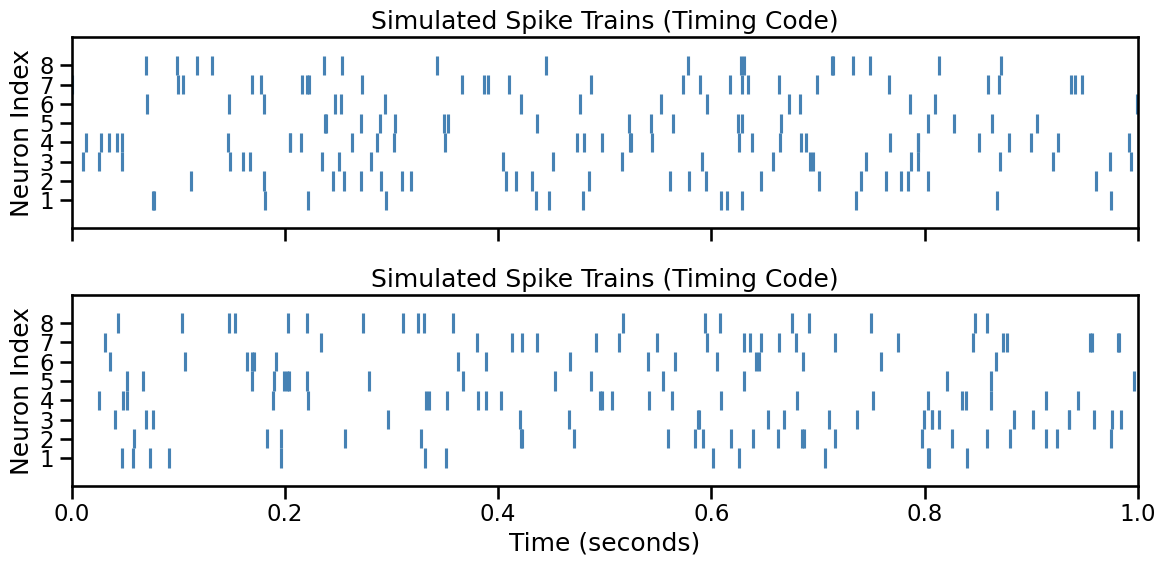

In [121]:
# --- Timing-code scenario: signal spikes buried in independent background noise ---
# generate_timing_code_spike_trains creates a precise per-neuron delay code
# (signal_rate=5 Hz) embedded in high-rate independent Poisson background
# (background_rate=15 Hz).  With a 4:1 background-to-signal ratio, all four
# SpikePhysics summary features are dominated by background and carry very
# little MI.  GRU, which processes actual spike timestamps, can learn to
# detect the signal spikes and capture the timing correlation.
np.random.seed(4)

pop_x_timing, pop_y_timing = nmi.generators.generate_timing_code_spike_trains(
    n_neurons=8, duration=200.0,
    signal_rate=5.0, background_rate=15.0,
    delay=0.015, jitter=0.003,
)

# Higher max_spikes_per_window to accommodate background + signal spikes
proc_spike_timing = dict(
    window_size=WINDOW_SIZE_SPIKE, step_size=0.25,
    max_spikes_per_window=30, n_seconds=200.0,
    no_spike_value=-1.0,
)

# visualize the simulated spike data
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for i in range(len(pop_x_timing)):
    spike_times = pop_x_timing[i]
    axes[0].eventplot(spike_times, lineoffsets=i, colors='steelblue')
axes[0].set_title('Simulated Spike Trains (Timing Code)')
axes[0].set_ylabel('Neuron Index')
for i in range(len(pop_y_timing)):
    spike_times = pop_y_timing[i]
    axes[1].eventplot(spike_times, lineoffsets=i, colors='steelblue')
axes[1].set_title('Simulated Spike Trains (Timing Code)')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Neuron Index')
plt.xlim(0, 1)  # zoom in on the first 20 seconds for visibility
axes[0].set_yticks(range(len(pop_x_timing)))
axes[0].set_yticklabels([f'{i+1}' for i in range(len(pop_x_timing))])
axes[1].set_yticks(range(len(pop_y_timing)))
axes[1].set_yticklabels([f'{i+1}' for i in range(len(pop_y_timing))])
plt.tight_layout()
plt.show()

In [122]:
print("\n--- GRU vs SpikePhysicsEmbedding (timing-code scenario) ---")
print("(timing code: signal spikes with precise delay buried in background noise)")

result_gru_timing = nmi.run(
    x_data=pop_x_timing, y_data=pop_y_timing,
    mode='sweep',
    processor_type_x='spike', processor_params_x=proc_spike_timing,
    processor_type_y='spike', processor_params_y=proc_spike_timing,
    base_params={**TIMING_PARAMS, 'embedding_model': 'gru'},
    show_progress=False, n_workers=5, # parallelize the sweeps across 5 cores (adjust as needed for your machine
    sweep_grid={'run_id': range(10)},  # Run 10 sweeps with different random seeds for error bars
)

result_physics_timing = nmi.run(
    x_data=pop_x_timing, y_data=pop_y_timing,
    mode='sweep',
    processor_type_x='spike', processor_params_x=proc_spike_timing,
    processor_type_y='spike', processor_params_y=proc_spike_timing,
    base_params={**TIMING_PARAMS, 'embedding_model': 'spike_physics'},
    show_progress=False, n_workers=5, # parallelize the sweeps across 5 cores (adjust as needed for your machine
    sweep_grid={'run_id': range(10)},  # Run 10 sweeps with different random seeds for error bars
)

result_physics_concat = nmi.run(
    x_data=pop_x_timing, y_data=pop_y_timing,
    mode='sweep',
    processor_type_x='spike', processor_params_x=proc_spike_timing,
    processor_type_y='spike', processor_params_y=proc_spike_timing,
    base_params={**TIMING_PARAMS, 'embedding_model': 'spike_physics',
                 'feature_fusion': 'concat'},
    show_progress=False, n_workers=5, # parallelize the sweeps across 5 cores (adjust as needed for your machine
    sweep_grid={'run_id': range(10)},  # Run 10 sweeps with different random seeds for error bars
)


--- GRU vs SpikePhysicsEmbedding (timing-code scenario) ---
(timing code: signal spikes with precise delay buried in background noise)


2026-04-22 10:42:36 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:42:36 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:42:36 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:42:36 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:42:36 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:43:48 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:43:48 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:43:48 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:43:48 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:43:48 - neural_mi - INFO - Created PairedDataset
/Users/eabdelaleem3/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Postdoc Projects/NeuralMI-Updating_21April2026/neural_mi/analysis/task.py:371: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0184 nats at epoch 12). The model failed to learn a generalising representation — this typically indicates too few epochs

In [123]:
res_sum_gru_timing = result_gru_timing.dataframe['train_mi']
res_sum_physics_timing = result_physics_timing.dataframe['train_mi']
res_sum_physics_concat = result_physics_concat.dataframe['train_mi']

print(f"  GRU:                            {res_sum_gru_timing.mean():.3f} ± {res_sum_gru_timing.std():.3f} bits")
print(f"  SpikePhysicsEmbed (features):   {res_sum_physics_timing.mean():.3f} ± {res_sum_physics_timing.std():.3f} bits")
print(f"  SpikePhysicsEmbed (concat):     {res_sum_physics_concat.mean():.3f} ± {res_sum_physics_concat.std():.3f} bits")

  GRU:                            0.164 ± 0.117 bits
  SpikePhysicsEmbed (features):   0.280 ± 0.219 bits
  SpikePhysicsEmbed (concat):     0.388 ± 0.190 bits


In the rate-code scenario, SpikePhysicsEmbedding should match or outperform
the GRU because the firing rate feature directly captures the MI.

In the timing-code scenario, the physics features (firing rate, mean spike
time, ISI mean/var) are dominated by background noise and carry little MI.
GRU, which processes the actual spike timestamps, can detect the correlated
signal spikes and should outperform the physics features. ``feature_fusion=
'concat'`` may further close the gap by supplementing the physics features
with the raw timestamps, giving the MLP head access to fine temporal detail.

**When to use ``spike_physics``:**
- When you suspect a rate code (e.g., sensory representations in cortex,
  population-rate-based decoding).
- As a fast, interpretable baseline: the physics features require no training
  and the mixer MLP is small.
- When you want to understand *which* statistic carries the MI — you can swap
  the four features and see which one matters.

**When to prefer ``gru`` / ``lstm``:**
- Precision-timing codes where exact millisecond-scale patterns matter.
- When ISIs alone are insufficient and you need the full temporal structure.

**``feature_fusion='concat'``:**
- Use when you are unsure whether the code is rate- or timing-based.
- Adds the normalised raw spike times to the physics features before mixing.
  The model can then use whichever representation is more informative.

## 4. PretrainedBackboneEmbedding for Image Data

### The inductive bias

When the input is an image (2D spatial data), a randomly initialized
convolutional network must learn to detect edges, textures, and objects from
scratch.  If your dataset has only a few thousand images, this is often
impossible.

``embedding_model='pretrained_backbone'`` solves this by loading a
**pretrained torchvision model** (ResNet, VGG, EfficientNet, …) and using
it as a frozen feature extractor.  Only a small trainable MLP head maps
the backbone's feature vector to ``embed_dim``.  The backbone has already
learned to detect the structures that matter in natural images, so the MLP
only needs to learn which of those features carry the MI.

**Important:** the backbone is always frozen (``requires_grad=False``).
The ``pretrained=True`` flag loads ImageNet weights; ``pretrained=False``
uses random backbone weights (useful to ablate the effect of pretraining).

Input data must be shape ``(n_samples, n_channels, height, width)`` — the
same format used by ``embedding_model='cnn2d'``.  Pass it directly to
``nmi.run`` with ``processor_type=None`` (no windowing).

**Requires** ``torchvision`` (``pip install torchvision``).

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.5628028..5.281222].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.2522845..5.122333].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.7804725..4.9706945].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.9378831..4.918417].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.5605316..5.3995943].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.1102295..5.3596315].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.3695345..

Image shapes: x=(500, 3, 64, 64), y=(500, 3, 64, 64)


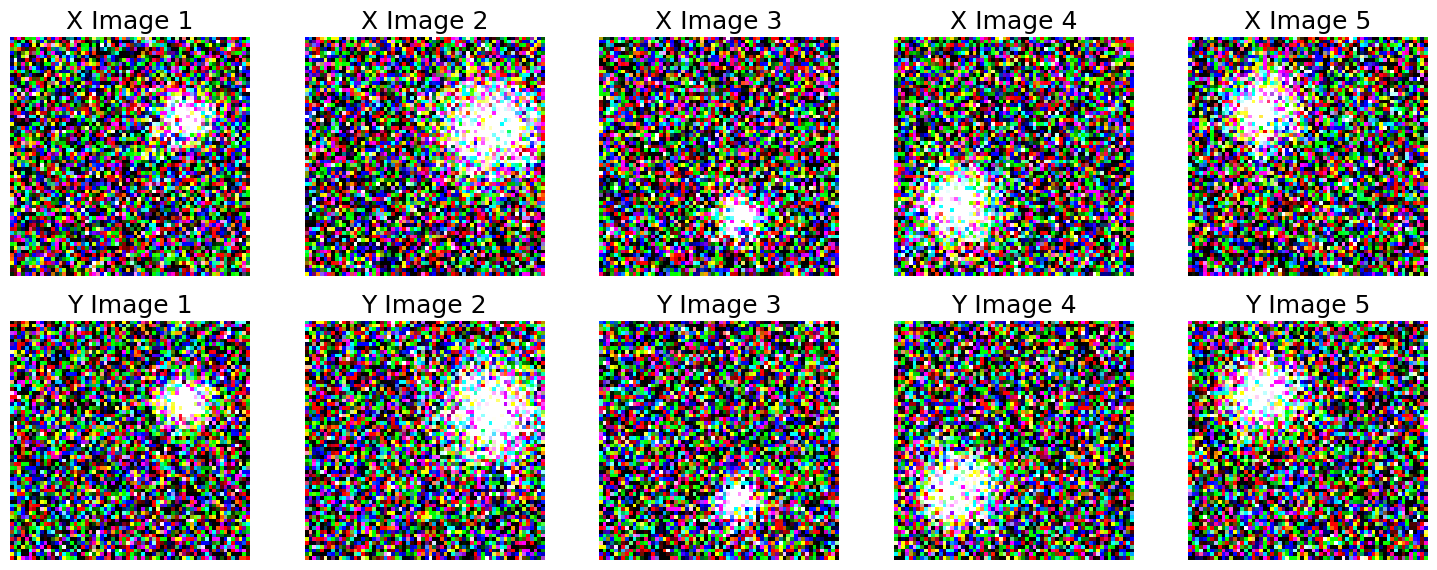

In [138]:
np.random.seed(5)

# Generate image pairs where X and Y share a Gaussian blob (same position,
# different noise realizations).  This is the simplest testable visual MI.
N_IMG = 500
x_img, y_img = nmi.generators.generate_noisy_image_pairs(
    n_samples=N_IMG, image_size=64, n_channels=3,
    signal_strength=2.5, noise_level=1.0,
)
# Shape: (N, 3, 64, 64) — ready for pretrained_backbone or cnn2d.
print(f"Image shapes: x={tuple(x_img.shape)}, y={tuple(y_img.shape)}")

# visualize some example image pairs
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    axes[0, i].imshow(np.transpose(x_img[i], (1, 2, 0)))  # convert from (C, H, W) to (H, W, C)
    axes[0, i].set_title(f'X Image {i+1}')
    axes[0, i].axis('off')
    axes[1, i].imshow(np.transpose(y_img[i],(1, 2, 0)))  # convert from (C, H, W) to (H, W, C)
    axes[1, i].set_title(f'Y Image {i+1}')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

In [139]:
print("--- CNN2D (random init) vs PretrainedBackbone (ResNet18, no pretraining) ---")

result_cnn2d = nmi.run(
    x_data=x_img, y_data=y_img,
    mode='sweep',
    split_mode='random',
    base_params={**FAST_PARAMS, 'embedding_model': 'cnn2d'},
    show_progress=True, n_workers=5, # parallelize the sweeps across 5 cores (adjust as needed for your machine
    sweep_grid={'run_id': range(10)},  # Run 10 sweeps with different random seeds for error bars
)

# pretrained=False for a fair comparison (both start from random weights,
# but pretrained_backbone uses ResNet18's architecture + frozen weights).
# Switch to pretrained=True to see the full power of transfer learning.
result_backbone_scratch = nmi.run(
    x_data=x_img, y_data=y_img,
    mode='sweep',
    split_mode='random',
    base_params={**FAST_PARAMS, 'embedding_model': 'pretrained_backbone',
                 'pytorch_predefined': 'resnet18', 'pretrained': False},
    show_progress=True, n_workers=5, # parallelize the sweeps across 5 cores (adjust as needed for your machine
    sweep_grid={'run_id': range(10)},  # Run 10 sweeps with different random seeds for error bars
)

result_backbone_pretrained = nmi.run(
    x_data=x_img, y_data=y_img,
    mode='sweep',
    split_mode='random',
    base_params={**FAST_PARAMS, 'embedding_model': 'pretrained_backbone',
                 'pytorch_predefined': 'resnet18', 'pretrained': True},
    show_progress=True, n_workers=5, # parallelize the sweeps across 5 cores (adjust as needed for your machine
    sweep_grid={'run_id': range(10)},  # Run 10 sweeps with different random seeds for error bars
)

--- CNN2D (random init) vs PretrainedBackbone (ResNet18, no pretraining) ---


Parameter Sweep Progress:   0%|          | 0/10 [00:00<?, ?task/s]2026-04-22 10:50:30 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:50:30 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:50:30 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:50:30 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:50:30 - neural_mi - INFO - Created PairedDataset
Parameter Sweep Progress:   0%|          | 0/10 [00:00<?, ?task/s]2026-04-22 10:55:48 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:55:48 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:55:48 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:55:48 - neural_mi - INFO - Created PairedDataset
2026-04-22 10:55:48 - neural_mi - INFO - Created PairedDataset
Run f0eee7d4-1da6-4d5b-a623-fc56dfbdf72e_c6 | MI: 0.306:  28%|██▊       | 28/100 [00:16<00:42,  1.69it/s]/Users/eabdelaleem3/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Postdoc Projects/NeuralMI-Updating_21April2026/neural_

In [140]:
res_sum_cnn2d = result_cnn2d.dataframe['train_mi']
res_sum_backbone_scratch = result_backbone_scratch.dataframe['train_mi']
res_sum_backbone_pretrained = result_backbone_pretrained.dataframe['train_mi']

print(f"  CNN2D (random init):           {res_sum_cnn2d.mean():.3f} ± {res_sum_cnn2d.std():.3f} bits")
print(f"  ResNet18 Backbone (scratch):   {res_sum_backbone_scratch.mean():.3f} ± {res_sum_backbone_scratch.std():.3f} bits")
print(f"  ResNet18 Backbone (pretrained):{res_sum_backbone_pretrained.mean():.3f} ± {res_sum_backbone_pretrained.std():.3f} bits")

  CNN2D (random init):           2.836 ± 0.110 bits
  ResNet18 Backbone (scratch):   1.245 ± 0.904 bits
  ResNet18 Backbone (pretrained):0.078 ± 0.170 bits


**Key parameters:**

- ``pytorch_predefined`` (str): any ``torchvision.models`` model name.
  Case-insensitive.  Examples: ``'resnet18'``, ``'resnet50'``, ``'vgg16'``,
  ``'efficientnet_b0'``.  Defaults to ``'resnet18'``.
- ``pretrained`` (bool): whether to load ImageNet weights.  Defaults to
  ``False``.  Set to ``True`` when your images are natural images or contain
  structures that overlap with ImageNet categories.

**When to use ``pretrained_backbone``:**
- Image data (2D spatial inputs).
- Small datasets where training a CNN from scratch is infeasible.
- When the relevant structure resembles natural image features (edges,
  textures, spatial patterns).

**When to skip:**
- Non-image data (time series, spikes, …).
- Highly domain-specific images with no overlap with natural images
  (e.g., raw microscopy data with unusual statistics).  In that case,
  consider starting from random weights (``pretrained=False``) and using
  a larger dataset.

## 5. The ``feature_fusion`` Parameter

All inductive-bias embedding models support a ``feature_fusion`` parameter
that controls what the downstream mixer sees:

- ``'features'`` (default): only the physics-derived features.
- ``'concat'``: physics features *concatenated with processed raw input*.

The case for ``'concat'`` is that physics features are compact summaries —
they may lose detail that the raw input retains.  For example:

- Spike timestamps: firing rate summarises the count, but exact spike timing
  (captured in the raw timestamps) may carry additional timing-code MI.
- EEG sinc features: bandpass-filtered signals capture band power, but the
  raw signal contains phase information that the features lose.

``'features'`` is the right default when you want a pure inductive bias
and a small, fast model.  Use ``'concat'`` when you are uncertain whether
the physics features are sufficient, or as an ablation study.

In [142]:
# Brief demonstration: spike_physics with features vs concat on rate code
print("--- feature_fusion comparison (rate-code spikes) ---")
print(f"  features only:   {res_sum_physics_concat.mean():.3f} ± {res_sum_physics_concat.std():.3f} bits  (shown above)")

result_concat = nmi.run(
    x_data=pop_x_rate, y_data=pop_y_rate,
    mode='sweep',
    processor_type_x='spike', processor_params_x=proc_spike,
    processor_type_y='spike', processor_params_y=proc_spike,
    base_params={**FAST_PARAMS, 'embedding_model': 'spike_physics',
                 'feature_fusion': 'concat'},
    show_progress=True, n_workers=5, # parallelize the sweeps across 5 cores (adjust as needed for your machine
    sweep_grid={'run_id': range(10)},  # Run 10 sweeps with different random seeds for error bars
)

--- feature_fusion comparison (rate-code spikes) ---
  features only:   0.388 ± 0.190 bits  (shown above)


Parameter Sweep Progress:   0%|          | 0/10 [00:00<?, ?task/s]2026-04-22 11:00:36 - neural_mi - INFO - Created PairedDataset
2026-04-22 11:00:36 - neural_mi - INFO - Created PairedDataset
2026-04-22 11:00:36 - neural_mi - INFO - Created PairedDataset
2026-04-22 11:00:36 - neural_mi - INFO - Created PairedDataset
2026-04-22 11:00:36 - neural_mi - INFO - Created PairedDataset
Parameter Sweep Progress: 100%|██████████| 10/10 [00:25<00:00,  2.51s/task]                               


In [143]:
res_sum_concat = result_concat.dataframe['train_mi']
print(f"  features + raw:  {res_sum_concat.mean():.3f} ± {res_sum_concat.std():.3f} bits")
print("(for a pure rate code the addition of raw timestamps should add little;")
print(" note: single-run variance is high — run multiple seeds for a reliable comparison)")

  features + raw:  1.509 ± 0.642 bits
(for a pure rate code the addition of raw timestamps should add little;
 note: single-run variance is high — run multiple seeds for a reliable comparison)


## 6. Quick Reference: Choosing the Right Model

| Data type | Recommended model | Notes |
|-----------|------------------|-------|
| Binned spike counts | ``'mlp'`` or ``'gru'`` | Short windows: MLP. Temporal order matters: GRU. |
| Binned spikes, many channels | ``'cnn'`` + ``use_depthwise=True`` | Per-channel filter before cross-channel mixing. |
| LFP / EEG (single channel) | ``'mlp'`` or ``'cnn'`` | Baseline. |
| LFP / EEG (band-limited MI) | ``'sinc_cnn'`` | Pass ``sample_rate``. Start with 8 filters. |
| LFP / EEG (multi-channel, band-limited) | ``'sinc_cnn'`` + ``use_depthwise`` in body | Not yet exposed as a single flag; use ``sinc_cnn`` (internally depthwise in first layer). |
| Raw spike timestamps (rate code) | ``'spike_physics'`` | Efficient, interpretable. |
| Raw spike timestamps (timing code) | ``'gru'`` or ``'spike_physics'`` + ``feature_fusion='concat'`` | Use GRU when signal spikes are buried in high-rate background. |
| Images | ``'pretrained_backbone'`` | Requires torchvision. Use ``pretrained=True`` for natural images. |
| General / unknown | ``'mlp'`` first, then sweep | Always start with MLP as the baseline. |

The general rule: **start with the MLP**.  Switch to an inductive-bias model
only when (a) you have domain knowledge about the data structure, and (b) the
MLP is failing to capture it.  Inductive biases are most valuable on limited
data; on large datasets, generic models often converge to the same result.

## Summary

NeuralMI now supports four physics-informed embedding choices:

1. **``use_depthwise=True``** on ``embedding_model='cnn'``: enforces per-channel
   temporal filtering before cross-channel mixing.  Drop-in upgrade for any
   multi-channel continuous or binned-spike analysis.

2. **``embedding_model='sinc_cnn'``**: learnable sinc bandpass filters
   initialized to EEG/LFP frequency bands.  Requires ``sample_rate`` in
   ``processor_params``.  Use when MI is band-limited.

3. **``embedding_model='spike_physics'``**: extracts firing rate, mean spike
   time, mean ISI, and ISI variance per neuron — no learned parameters in
   the feature stage.  Use for rate codes; combine with ``feature_fusion='concat'``
   for timing codes.

4. **``embedding_model='pretrained_backbone'``**: frozen torchvision backbone
   + trainable MLP head.  Use for image data, especially with small datasets.
   Specify the backbone with ``pytorch_predefined`` (e.g., ``'resnet18'``).

All four models are fully compatible with ``mode='sweep'``,
``mode='rigorous'``, variational wrappers, custom critics, and the full
NeuralMI pipeline.